- Lektion 5 - Scikit-learn API (Del 2)
- Assignment: Unsupervised learning with K-Means and PCA

Instructions:
1. Work with a numeric dataset
2. Visualize results
3. Add short comments to explain your plots

# Task 1: K-Means clustering
- TODO: Load a numeric dataset (iris features or another)
- TODO: Standardize the features
- TODO: Try k = 1..8 and compute inertia
- TODO: Plot the elbow curve and choose k

In [14]:
from sklearn.datasets import load_iris
import pandas as pd

data = load_iris(as_frame=True)

X = data.data
y = data.target

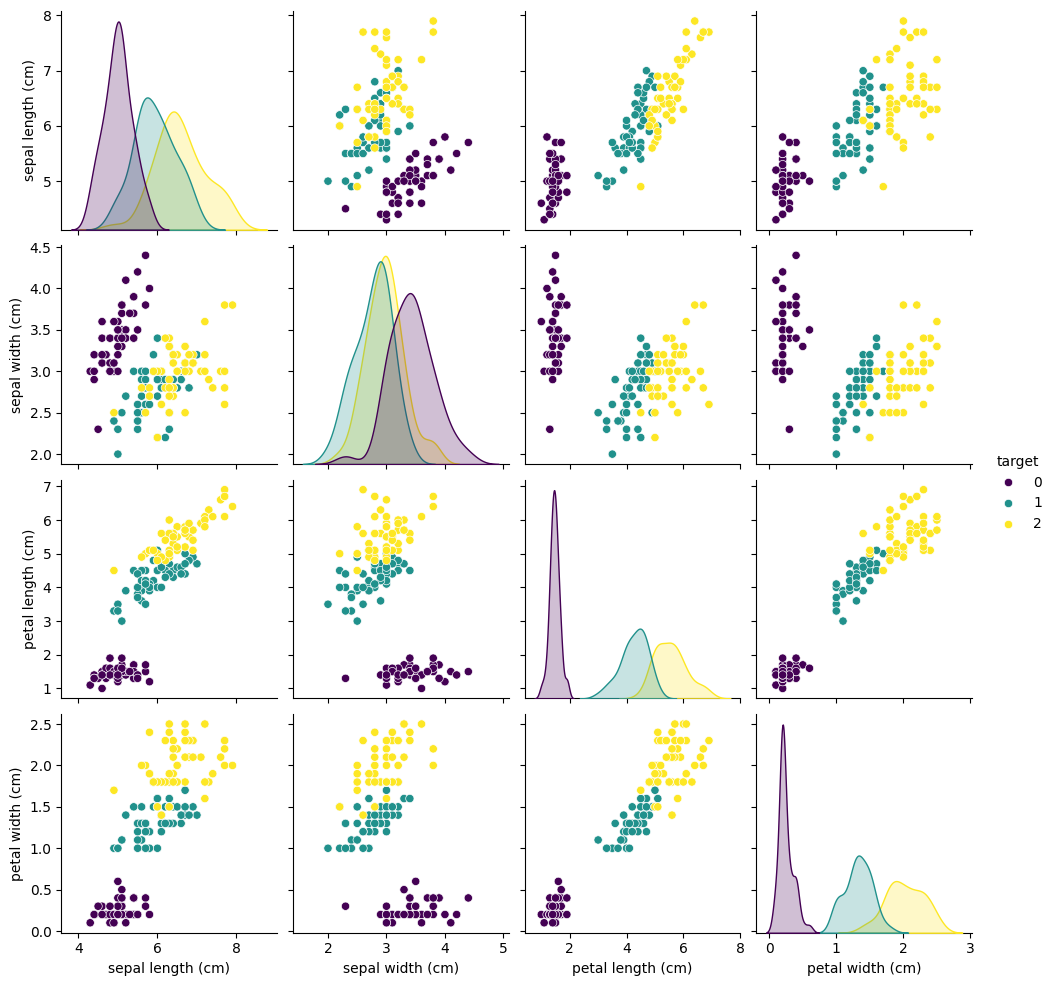

In [15]:
# Extra EDA step, we plot the data

import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(data=data.frame, hue="target", vars=data.feature_names, palette="viridis")
plt.show()



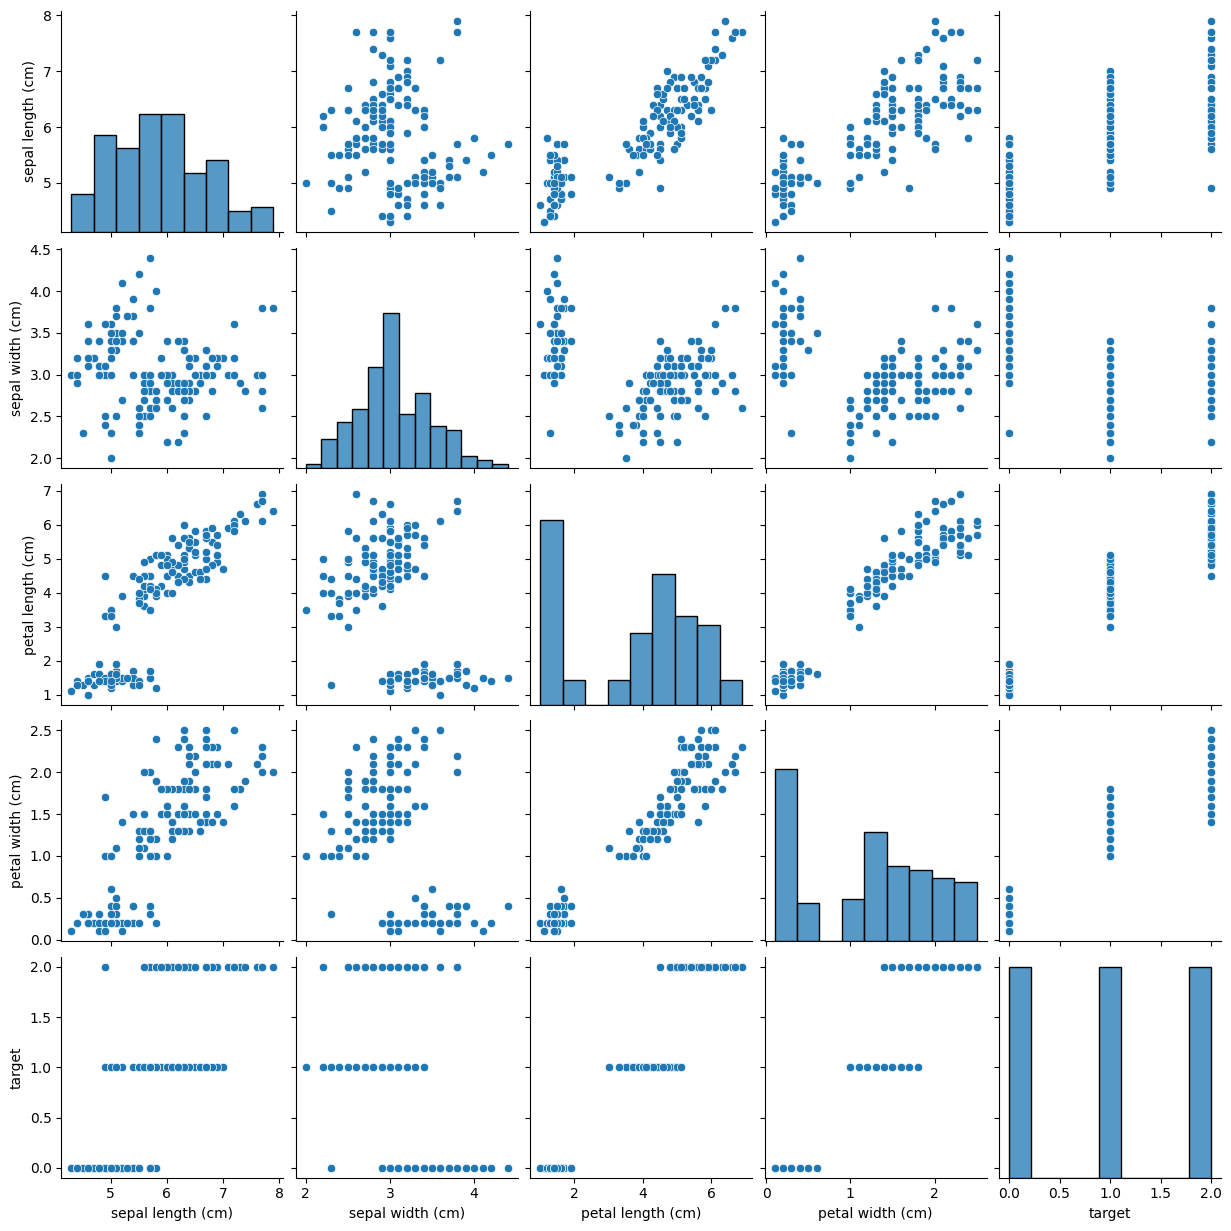

In [16]:
sns.pairplot(data.frame)

In [17]:
# Standardize the features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [19]:
X_scaled[:,1].std()

np.float64(1.0000000000000004)

In [20]:
print("X before scaling:", X)
print("X after scaling:", X_scaled)

X before scaling:      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]
X after scaling: [[-9.

In [21]:
# TODO: Try k = 1..8 and compute inertia
from sklearn.cluster import KMeans

# Try k = 1..8 and compute inertia (elbow)
# Intertia: hur lika klustrena är inombords

# I loopen nedan så tränar vi KMeans-modeller med flera olika K
# för att utvärdera vilket som ger bäst resultat
# ALLTSÅ: Hur många kluster vi rimligtvis har i vår data
ks = range(1, 9)
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

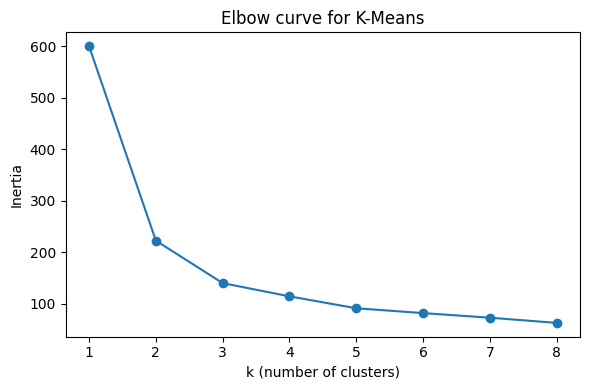

In [22]:
# TODO: Plot the elbow curve and choose k

# I plotten ser det lite ut som att vi har en elbow vid k=2?
# Men kanske även en liten vid k=3?

# För vår data är det här rimligt, med våra ögon ser det 
# ut som att datan kanske skulle kunna vara 2 kluster, och kanske 3.
# I praktiken kanske vi testar att klustra bägge

plt.figure(figsize=(6, 4))
plt.plot(list(ks), inertias, marker="o")
plt.title("Elbow curve for K-Means")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

In [23]:
# Choose k = 3 (reasonable for IRIS) and fit 

k_best = 3
km_best = KMeans(n_clusters=k_best, random_state=42, n_init=10)
cluster_labels = km_best.fit_predict(X_scaled)

# Task 2: PCA visualization
- TODO: Apply PCA with n_components=2
- TODO: Plot the 2D projection
- TODO: Color by true labels (if available) or by cluster labels

In [24]:
# Apply PCA with n_components=2

from sklearn.decomposition import PCA

# PCA handlar om att reducera högdimensionell data till lägre dimensioner
# Den är ganska bra på att behålla relationer
# Vi sätter en parameter n_components, som är hur många dimensioner vi vill ha, typiskt 2

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)



In [25]:
X_pca

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538],
       [-2.07563095,  1.48917752],
       [-2.44402884,  0.0476442 ],
       [-2.23284716,  0.22314807],
       [-2.33464048, -1.11532768],
       [-2.18432817, -0.46901356],
       [-2.1663101 ,  1.04369065],
       [-2.32613087,  0.13307834],
       [-2.2184509 , -0.72867617],
       [-2.6331007 , -0.96150673],
       [-2.1987406 ,  1.86005711],
       [-2.26221453,  2.68628449],
       [-2.2075877 ,  1.48360936],
       [-2.19034951,  0.48883832],
       [-1.898572  ,  1.40501879],
       [-2.34336905,  1.12784938],
       [-1.914323  ,  0.40885571],
       [-2.20701284,  0.92412143],
       [-2.7743447 ,  0.45834367],
       [-1.81866953,  0.08555853],
       [-2.22716331,  0.13725446],
       [-1.95184633, -0.62561859],
       [-2.05115137,  0.24216355],
       [-2.16857717,  0.52714953],
       [-2.13956345,

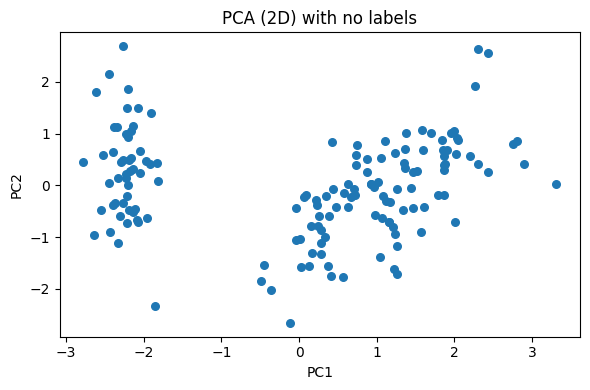

In [26]:
# Plot the 2D projection

# Plot PCA projection colored by true labels
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=30)
plt.title("PCA (2D) with no labels")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


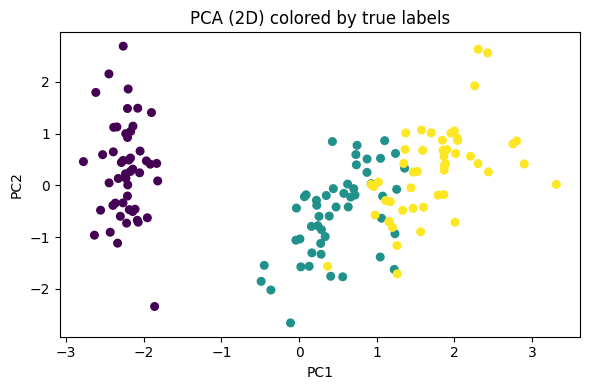

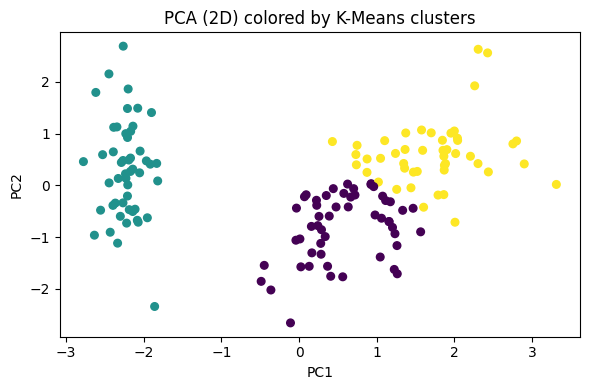

In [27]:
# TODO: Color by true labels (if available) or by cluster labels

# Plot PCA projection colored by true labels
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis", s=30)
plt.title("PCA (2D) colored by true labels")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# Plot PCA projection colored by cluster labels
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis", s=30)
plt.title("PCA (2D) colored by K-Means clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

IndexError: index 2 is out of bounds for axis 1 with size 2

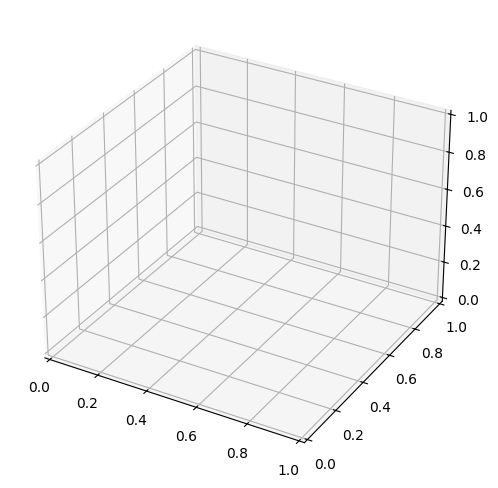

In [28]:
# BONUS: Plot our 3D pca projection colored by true labels
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt 
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y, cmap="viridis", s=30)
ax.set_title("PCA (3D) colored by true labels")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.tight_layout()
plt.show()